In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os

# dataset_path = "/kaggle/input/deepfake-and-real-images"
# files = os.listdir(dataset_path)

# print(files)
# dataset_folder_path = os.path.join(dataset_path, 'Dataset')
# dataset_files = os.listdir(dataset_folder_path)

# print(dataset_files)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailpromus/skin-diseases-image-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/skin-diseases-image-dataset


In [3]:
import os

dataset_path = "/kaggle/input/skin-diseases-image-dataset"
files = os.listdir(dataset_path)

print(files)
img_classes_path = os.path.join(dataset_path, 'IMG_CLASSES')
img_classes_files = os.listdir(img_classes_path)
print(img_classes_files)


['IMG_CLASSES']
['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '4. Basal Cell Carcinoma (BCC) 3323', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '5. Melanocytic Nevi (NV) - 7970', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k', '3. Atopic Dermatitis - 1.25k', '6. Benign Keratosis-like Lesions (BKL) 2624', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '2. Melanoma 15.75k']


In [4]:
import re
from collections import defaultdict

raw_classes = ['1. Eczema 1677',
    '10. Warts Molluscum and other Viral Infections - 2103',
    '4. Basal Cell Carcinoma (BCC) 3323',
    '7. Psoriasis pictures Lichen Planus and related diseases - 2k',
    '5. Melanocytic Nevi (NV) - 7970',
    '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k',
    '3. Atopic Dermatitis - 1.25k',
    '6. Benign Keratosis-like Lesions (BKL) 2624',
    '8. Seborrheic Keratoses and other Benign Tumors - 1.8k',
    '2. Melanoma 15.75k']

def parse_class(raw_classes):
    cleaned = {}
    for item in raw_classes:
        match = re.match(r'\d+\.\s+(.*?)\s*[-]?\s*(\d+(?:\.\d+)?k?)$', item.strip())
        if match: 
            name,count = match.groups()
            count = count.lower().strip()
            if count.endswith('k'):
                count = float(count[:-1]) * 1000
            else:
                count = float(count)
            cleaned[name.strip()] = int(count)
    return cleaned
            
parsed_classes = parse_class(raw_classes)
print(parsed_classes)

{'Eczema': 1677, 'Warts Molluscum and other Viral Infections': 2103, 'Basal Cell Carcinoma (BCC)': 3323, 'Psoriasis pictures Lichen Planus and related diseases': 2000, 'Melanocytic Nevi (NV)': 7970, 'Tinea Ringworm Candidiasis and other Fungal Infections': 1700, 'Atopic Dermatitis': 1250, 'Benign Keratosis-like Lesions (BKL)': 2624, 'Seborrheic Keratoses and other Benign Tumors': 1800, 'Melanoma': 15750}


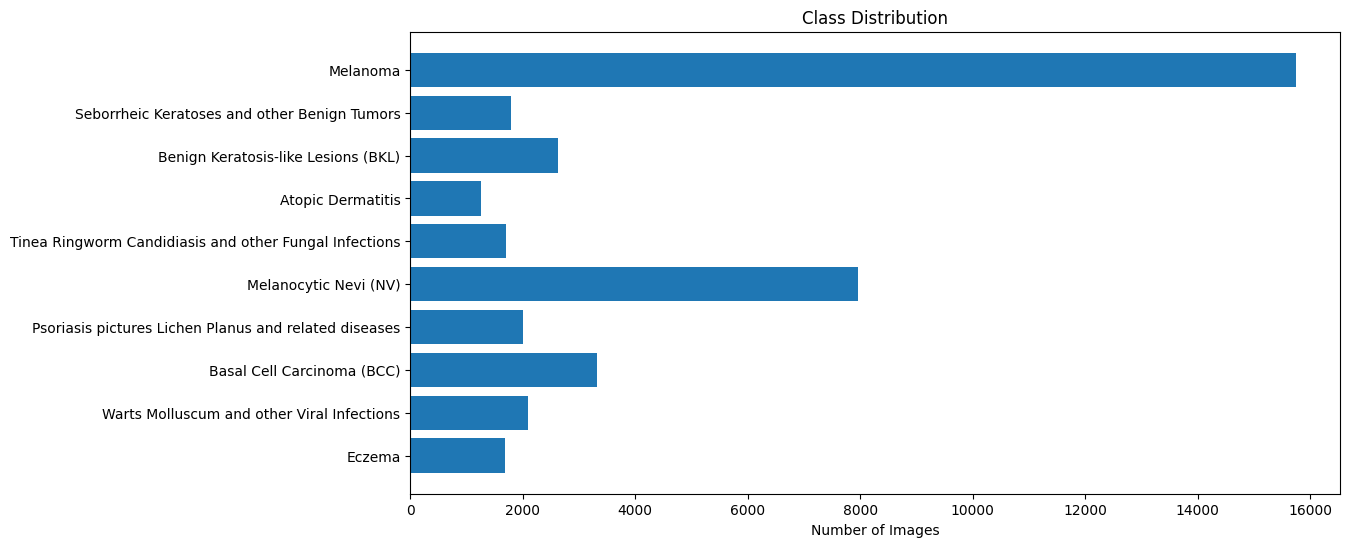

In [5]:
import matplotlib.pyplot as plt

labels = list(parsed_classes.keys())
counts = list(parsed_classes.values())
plt.figure(figsize = (12,6))
plt.barh(labels, counts)
plt.title('Class Distribution')
plt.xlabel('Number of Images')
plt.show()

1. Eczema 1677
10. Warts Molluscum and other Viral Infections - 2103
4. Basal Cell Carcinoma (BCC) 3323
7. Psoriasis pictures Lichen Planus and related diseases - 2k
5. Melanocytic Nevi (NV) - 7970
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k
3. Atopic Dermatitis - 1.25k
6. Benign Keratosis-like Lesions (BKL) 2624
8. Seborrheic Keratoses and other Benign Tumors - 1.8k
2. Melanoma 15.75k
[1.5, 0.6625, 1.5254237288135593, 1.5254237288135593, 1.509433962264151, 0.6625, 0.6972222222222222, 1.5254237288135593, 0.6625, 0.6833333333333333, 0.6625, 1.5254237288135593, 1.3243243243243243, 1.5, 0.6625, 0.6625, 1.5, 1.5254237288135593, 1.3243243243243243, 1.3243243243243243, 1.5254237288135593, 1.509433962264151, 0.6625, 0.6666666666666666, 1.3243243243243243, 1.3243243243243243, 1.5254237288135593, 1.5254237288135593, 1.5, 0.6625, 0.6625, 1.5, 1.4285714285714286, 1.4754098360655739, 1.5, 1.5254237288135593, 1.5254237288135593, 1.3243243243243243, 1.5254237288135593, 1.5254237

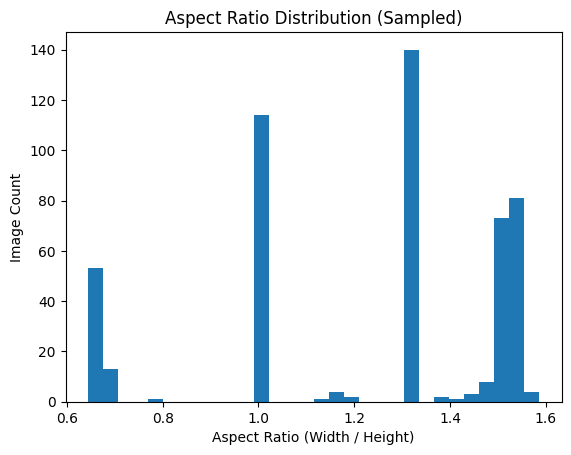

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/skin-diseases-image-dataset"
sample_size_per_class = 50  # tweak as needed
aspect_ratios = []
img_classes_path = os.path.join(dataset_path, 'IMG_CLASSES')
img_classes_files = os.listdir(img_classes_path)

for class_name in img_classes_files:
    print(class_name)
    class_dir = os.path.join(img_classes_path, class_name)

    if not os.path.isdir(class_dir): continue

    files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    sampled_files = random.sample(files, min(sample_size_per_class, len(files)))

    for file in sampled_files:
        img_path = os.path.join(class_dir, file)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                aspect_ratios.append(w / h)
        except:
            continue
print(aspect_ratios)
# Visualize
plt.hist(aspect_ratios, bins=30)
plt.xlabel('Aspect Ratio (Width / Height)')
plt.ylabel('Image Count')
plt.title('Aspect Ratio Distribution (Sampled)')
plt.show()


In [7]:
import torch
from torch.utils.data import Subset
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

dataset_root = "/kaggle/input/skin-diseases-image-dataset/IMG_CLASSES"
full_dataset = ImageFolder(root=dataset_root) 

total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

torch.manual_seed(42)
train_subset, val_subset, test_subset = random_split(full_dataset, [train_size, val_size, test_size])


In [8]:
import torchvision.transforms as transforms
from torchvision.transforms import functional as F

class PadToSquare:
    def __call__(self, img):
        w, h = img.size
        max_side = max(w, h)
        padding = (
            (max_side - w) // 2,  # left
            (max_side - h) // 2,  # top
            (max_side - w + 1) // 2,  # right
            (max_side - h + 1) // 2,  # bottom
        )
        return F.pad(img, padding, fill=0, padding_mode='constant')

In [9]:
light_augmented_classes = ['2. Melanoma 15.75k','5. Melanocytic Nevi (NV) - 7970']



In [10]:
import torch
from torchvision import transforms

imagenet_mean =[0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]
light_augmentation = transforms.Compose([PadToSquare(),transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

strong_augmentation = transforms.Compose([PadToSquare(),transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


In [11]:
val_test_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [12]:
train_strong = ImageFolder(root=dataset_root, transform=strong_augmentation)
train_light  = ImageFolder(root=dataset_root, transform=light_augmentation)

train_strong.samples = [
    s for i, s in enumerate(full_dataset.samples)
    if i in train_subset.indices and full_dataset.classes[s[1]] not in light_augmented_classes
]

train_light.samples = [
    s for i, s in enumerate(full_dataset.samples)
    if i in train_subset.indices and full_dataset.classes[s[1]] in light_augmented_classes
]

train_dataset = train_strong + train_light



In [13]:
val_dataset = ImageFolder(root=dataset_root, transform=val_test_transform)
val_dataset.samples = [val_dataset.samples[i] for i in val_subset.indices]

test_dataset = ImageFolder(root=dataset_root, transform=val_test_transform)
test_dataset.samples = [test_dataset.samples[i] for i in test_subset.indices]


In [14]:
import torchvision.models as models
import torch.nn as nn
import torch

# === Load Pretrained EfficientNetB3 ===
model = models.efficientnet_b3(weights='IMAGENET1K_V1')

# === Replace Classifier Head ===
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 10)  # Adjust based on your number of classes
)

model = model.to('cuda' if torch.cuda.is_available() else 'cpu')


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 209MB/s]


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

def freeze_everything_except_classifier(model):
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True
    print("Phase 1 - Training only classifier")

def unfreeze_last_block(model):
    for name, param in model.named_parameters():
        if "features.7" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    print("Phase 2 - Training last block + classifier")

def unfreeze_last_two_blocks(model):
    for name, param in model.named_parameters():
        if "features.6" in name or "features.7" in name or "classifier" in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    print("Phase 3 - Training last two blocks + classifier")


In [16]:
def train_model(model, train_loader, val_loader, device, criterion, total_epochs=15):
    from sklearn.metrics import f1_score

    phase_epochs = [5, 5, 5]
    phase_funcs = [freeze_everything_except_classifier, unfreeze_last_block, unfreeze_last_two_blocks]

    for phase_idx, phase_func in enumerate(phase_funcs):
        phase_func(model)
        lr = [1e-3, 1e-4, 1e-5][phase_idx]
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

        for epoch in range(phase_epochs[phase_idx]):
            model.train()
            running_loss = 0.0
            all_preds = []
            all_labels = []

            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Calculate train metrics
            avg_loss = running_loss / len(train_loader)
            train_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).sum().item() / len(all_labels)
            train_f1 = f1_score(all_labels, all_preds, average='macro')

            # Validation metrics
            val_acc, val_f1 = evaluate_model(model, val_loader, device)

            print(f"Phase {phase_idx+1}, Epoch {epoch+1}/{phase_epochs[phase_idx]} | "
                  f"Train Loss: {avg_loss:.4f} | "
                  f"Train Acc: {train_acc:.2%} | Train F1: {train_f1:.4f} | "
                  f"Val Acc: {val_acc:.2%} | Val F1: {val_f1:.4f}")

   
            checkpoint_filename = f"efficientnet_phase{phase_idx+1}_epoch{epoch+1}.pth"
            torch.save(model.state_dict(), checkpoint_filename)
            print(f" Model saved as {checkpoint_filename}")


In [17]:
def evaluate_model(model, data_loader, device):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    f1 = f1_score(all_labels, all_preds, average='macro')  # or 'weighted'
    return acc, f1


In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_strong = [label for _, label in train_strong.samples]
train_labels_light = [label for _, label in train_light.samples]
train_labels = train_labels_strong + train_labels_light

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

In [19]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights_tensor = class_weights_tensor.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


train_model(model, train_loader, val_loader, device, criterion, total_epochs=15)


Phase 1 - Training only classifier
Phase 1, Epoch 1/5 | Train Loss: 1.3067 | Train Acc: 64.74% | Train F1: 0.5106 | Val Acc: 65.59% | Val F1: 0.5239
 Model saved as efficientnet_phase1_epoch1.pth
Phase 1, Epoch 2/5 | Train Loss: 1.0926 | Train Acc: 69.44% | Train F1: 0.5688 | Val Acc: 66.40% | Val F1: 0.5373
 Model saved as efficientnet_phase1_epoch2.pth
Phase 1, Epoch 3/5 | Train Loss: 1.0596 | Train Acc: 70.50% | Train F1: 0.5831 | Val Acc: 66.21% | Val F1: 0.5400
 Model saved as efficientnet_phase1_epoch3.pth
Phase 1, Epoch 4/5 | Train Loss: 1.0420 | Train Acc: 71.00% | Train F1: 0.5886 | Val Acc: 66.38% | Val F1: 0.5499
 Model saved as efficientnet_phase1_epoch4.pth
Phase 1, Epoch 5/5 | Train Loss: 1.0276 | Train Acc: 71.39% | Train F1: 0.5949 | Val Acc: 65.77% | Val F1: 0.5385
 Model saved as efficientnet_phase1_epoch5.pth
Phase 2 - Training last block + classifier
Phase 2, Epoch 1/5 | Train Loss: 0.9540 | Train Acc: 73.65% | Train F1: 0.6223 | Val Acc: 69.55% | Val F1: 0.5890
 Mo